In [2]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available. Enable T4 GPU from Runtime > Change runtime type.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

SYSTEM INFORMATION
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Selected device: cuda


In [3]:
!pip install -q kagglehub scikit-learn seaborn tqdm

In [4]:
import os
import shutil
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [6]:
import kagglehub

print("=" * 60)
print("DOWNLOADING CIFAKE DATASET")
print("=" * 60)

dataset_path = kagglehub.dataset_download(
    "birdy654/cifake-real-and-ai-generated-synthetic-images"
)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset_path)

DOWNLOADING CIFAKE DATASET
Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Dataset downloaded successfully.
Dataset location: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [7]:
print("=" * 60)
print("DATASET FOLDER STRUCTURE")
print("=" * 60)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)

    for file in files[:5]:
        print(f"{subindent}{file}")

    if level >= 2:
        dirs[:] = []

DATASET FOLDER STRUCTURE
cifake-real-and-ai-generated-synthetic-images/
    test/
        FAKE/
            943 (5).jpg
            534 (7).jpg
            81 (2).jpg
            869 (9).jpg
            610 (10).jpg
        REAL/
            0664.jpg
            0280 (6).jpg
            0816 (6).jpg
            0704 (5).jpg
            0896 (9).jpg
    train/
        FAKE/
            5387 (6).jpg
            4093 (7).jpg
            5357 (8).jpg
            3825 (3).jpg
            4131 (5).jpg
        REAL/
            4093 (7).jpg
            3825 (3).jpg
            4131 (5).jpg
            2270 (7).jpg
            3263 (8).jpg


In [8]:
dataset_path = Path(dataset_path)

possible_train = list(dataset_path.rglob("train"))
possible_test = list(dataset_path.rglob("test"))

print("Possible train folders:", possible_train)
print("Possible test folders:", possible_test)

train_dir = possible_train[0]
test_dir = possible_test[0]

print("\nSelected train directory:", train_dir)
print("Selected test directory:", test_dir)

Possible train folders: [PosixPath('/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train')]
Possible test folders: [PosixPath('/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test')]

Selected train directory: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train
Selected test directory: /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test


In [9]:
def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    counts = {}

    for class_folder in sorted(folder.iterdir()):
        if class_folder.is_dir():
            count = sum(
                1 for file in class_folder.rglob("*")
                if file.suffix.lower() in extensions
            )
            counts[class_folder.name] = count

    return counts


train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print("Training dataset:")
for class_name, count in train_counts.items():
    print(f"  {class_name}: {count:,} images")

print("\nTesting dataset:")
for class_name, count in test_counts.items():
    print(f"  {class_name}: {count:,} images")

print("\nTotal training images:", sum(train_counts.values()))
print("Total testing images:", sum(test_counts.values()))
print("Total images:", sum(train_counts.values()) + sum(test_counts.values()))

DATASET STATISTICS
Training dataset:
  FAKE: 50,000 images
  REAL: 50,000 images

Testing dataset:
  FAKE: 10,000 images
  REAL: 10,000 images

Total training images: 100000
Total testing images: 20000
Total images: 120000


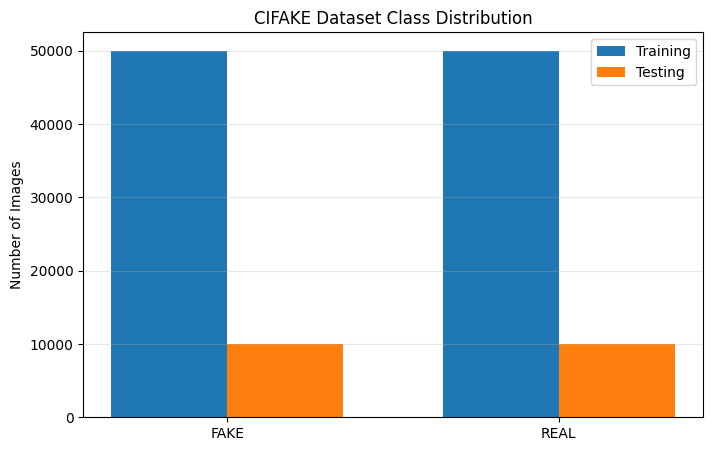

Class distribution graph generated.


In [10]:
classes = list(train_counts.keys())
train_values = list(train_counts.values())
test_values = list(test_counts.values())

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, train_values, width, label="Training")
plt.bar(x + width/2, test_values, width, label="Testing")

plt.xticks(x, classes)
plt.ylabel("Number of Images")
plt.title("CIFAKE Dataset Class Distribution")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

print("Class distribution graph generated.")

In [11]:
IMG_SIZE = 32
BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformations defined.")
print("Evaluation transformations defined.")
print("Image size:", IMG_SIZE, "x", IMG_SIZE)

Training transformations defined.
Evaluation transformations defined.
Image size: 32 x 32


In [12]:
# Dataset with augmentation for training
full_train_aug = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

# Dataset without augmentation for validation
full_train_eval = datasets.ImageFolder(
    root=train_dir,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=eval_transform
)

class_names = full_train_aug.classes
class_to_idx = full_train_aug.class_to_idx

print("=" * 60)
print("DATASET LOADING")
print("=" * 60)

print("Classes:", class_names)
print("Class mapping:", class_to_idx)
print("Training images available:", len(full_train_aug))
print("Testing images available:", len(test_dataset))

# Create reproducible 80/20 train-validation split
indices = list(range(len(full_train_aug)))

random.seed(SEED)
random.shuffle(indices)

split_index = int(0.8 * len(indices))

train_indices = indices[:split_index]
val_indices = indices[split_index:]

train_dataset = Subset(full_train_aug, train_indices)
val_dataset = Subset(full_train_eval, val_indices)

print("\nTrain images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

print("\nSplit percentages:")
print(f"Training: {len(train_dataset)/len(full_train_aug)*100:.2f}%")
print(f"Validation: {len(val_dataset)/len(full_train_aug)*100:.2f}%")
print("Testing: Original CIFAKE test set kept untouched.")

DATASET LOADING
Classes: ['FAKE', 'REAL']
Class mapping: {'FAKE': 0, 'REAL': 1}
Training images available: 100000
Testing images available: 20000

Train images: 80000
Validation images: 20000
Test images: 20000

Split percentages:
Training: 80.00%
Validation: 20.00%
Testing: Original CIFAKE test set kept untouched.


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("DATALOADERS CREATED")
print("=" * 60)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

DATALOADERS CREATED
Training batches: 2500
Validation batches: 625
Testing batches: 625
Batch size: 32


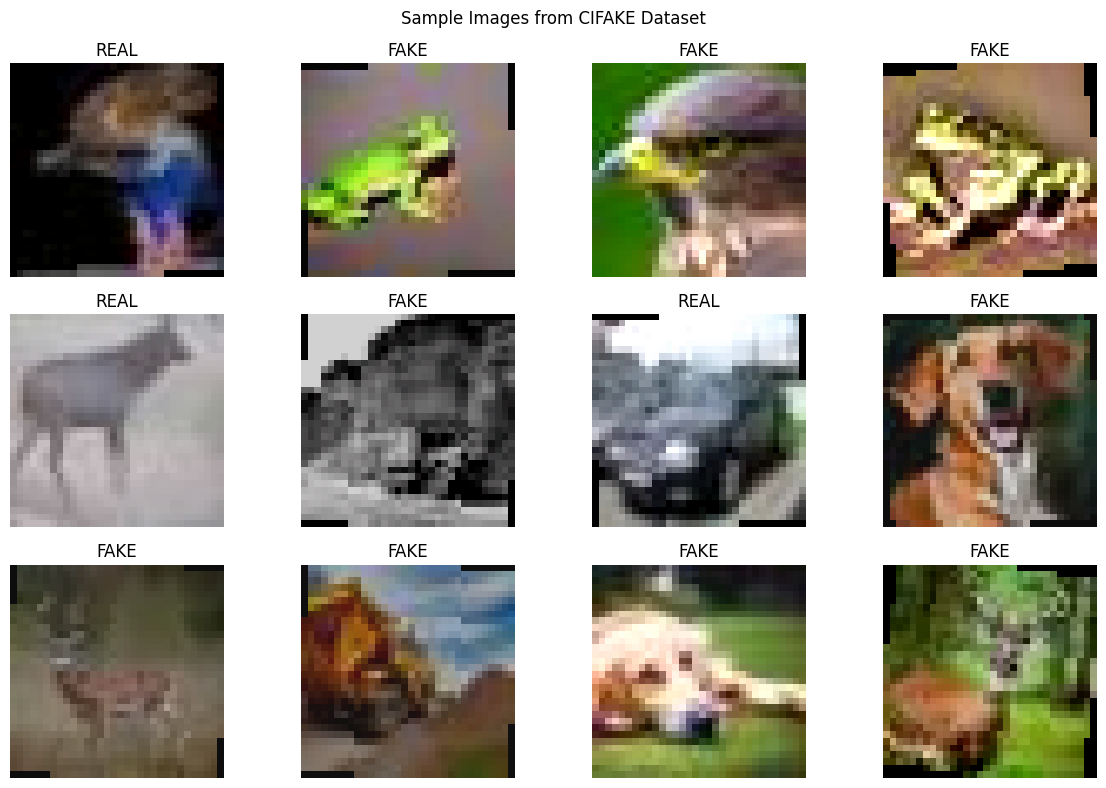

Displayed sample images from the training dataset.


In [14]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image * std + mean
    return torch.clamp(image, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)

    image = denormalize(images[i]).permute(1, 2, 0).numpy()

    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.suptitle("Sample Images from CIFAKE Dataset")
plt.tight_layout()
plt.show()

print("Displayed sample images from the training dataset.")

In [15]:
print("=" * 60)
print("LOADING RESNET-50 MODEL FOR NATIVE 32x32 IMAGES")
print("=" * 60)

weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Adapt the first layers for native 32x32 images.
# Keep the pretrained later layers and replace the ImageNet stem.
model.conv1 = nn.Conv2d(
    3, 64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)
nn.init.kaiming_normal_(
    model.conv1.weight,
    mode="fan_out",
    nonlinearity="relu"
)
model.maxpool = nn.Identity()

# Replace the final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

print("Model: ResNet-50")
print("Pretrained weights: ImageNet (adapted native 32x32 stem)")
print("Input size:", IMG_SIZE, "x", IMG_SIZE)
print("Original final layer features:", num_features)
print("New output classes:", class_names)
print("Model moved to:", device)


LOADING RESNET-50 MODEL FOR NATIVE 32x32 IMAGES
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 80.7MB/s]


Model: ResNet-50
Pretrained weights: ImageNet (adapted native 32x32 stem)
Input size: 32 x 32
Original final layer features: 2048
New output classes: ['FAKE', 'REAL']
Model moved to: cuda


In [16]:
# ============================================================
# CLASS-WEIGHTED LOSS + COSINE SCHEDULER
# ============================================================

# Upweight REAL class (class 1) to reduce False Negatives (REAL misclassified as FAKE)
class_weights = torch.tensor([1.0, 1.4]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=12,
    eta_min=1e-6
)

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Loss function: CrossEntropyLoss (weighted: FAKE=1.0, REAL=1.4)")
print("Optimizer: AdamW")
print("Learning rate:", 1e-4)
print("Weight decay:", 1e-4)
print("Scheduler: CosineAnnealingLR (T_max=12, eta_min=1e-6)")


TRAINING CONFIGURATION
Loss function: CrossEntropyLoss (weighted: FAKE=1.0, REAL=1.4)
Optimizer: AdamW
Learning rate: 0.0001
Weight decay: 0.0001
Scheduler: CosineAnnealingLR (T_max=12, eta_min=1e-6)


In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation", leave=False)

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )


print("Training and evaluation functions are ready.")

Training and evaluation functions are ready.


In [18]:
from sklearn.metrics import f1_score as sk_f1

NUM_EPOCHS = 12

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_f1": []
}

best_val_accuracy = 0.0
best_val_f1 = 0.0
best_model_path = "/content/best_resnet50_cifake_native32.pth"

print("=" * 60)
print("STARTING MODEL TRAINING")
print("=" * 60)

print("Epochs:", NUM_EPOCHS)
print("Device:", device)
print("Best model will be saved at:", best_model_path)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("-" * 40)

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy, val_labels, val_preds, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # Cosine scheduler takes no argument (unlike ReduceLROnPlateau)
    scheduler.step()

    val_f1 = sk_f1(val_labels, val_preds, average="macro")
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)
    history["val_f1"].append(val_f1)

    # Save best model by Macro F1 (more sensitive to REAL class errors)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "class_to_idx": class_to_idx,
            "img_size": IMG_SIZE
        }, best_model_path)

        print(f"  Best model saved (Val F1: {best_val_f1:.4f})")

    epoch_time = time.time() - epoch_start

    print(f"Train Loss:      {train_loss:.4f}")
    print(f"Train Accuracy:  {train_accuracy:.4f}")
    print(f"Val Loss:        {val_loss:.4f}")
    print(f"Val Accuracy:    {val_accuracy:.4f}")
    print(f"Val F1 (Macro):  {val_f1:.4f}")
    print(f"Learning Rate:   {current_lr:.8f}")
    print(f"Epoch Time:      {epoch_time/60:.2f} minutes")

total_time = time.time() - start_time

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(f"Total training time: {total_time/60:.2f} minutes")
print(f"Best validation F1:  {best_val_f1:.4f}")
print(f"Best model saved at: {best_model_path}")


STARTING MODEL TRAINING
Epochs: 12
Device: cuda
Best model will be saved at: /content/best_resnet50_cifake_native32.pth

Epoch [1/12]
----------------------------------------


Training:   0%|          | 0/2500 [00:00<?, ?it/s]

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

  Best model saved (Val F1: 0.9547)
Train Loss:      0.2254
Train Accuracy:  0.9047
Val Loss:        0.1153
Val Accuracy:    0.9547
Val F1 (Macro):  0.9547
Learning Rate:   0.00009831
Epoch Time:      5.77 minutes

Epoch [2/12]
----------------------------------------


Training:   0%|          | 0/2500 [00:00<?, ?it/s]

...

  Best model saved (Val F1: 0.9827)
Train Loss:      0.0099
Train Accuracy:  0.9963
Val Loss:        0.0603
Val Accuracy:    0.9828
Val F1 (Macro):  0.9827
Learning Rate:   0.00000269
Epoch Time:      5.76 minutes

Epoch [12/12]
----------------------------------------


Training:   0%|          | 0/2500 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d90061c7380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d90061c7380>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

  Best model saved (Val F1: 0.9828)
Train Loss:      0.0080
Train Accuracy:  0.9972
Val Loss:        0.0562
Val Accuracy:    0.9829
Val F1 (Macro):  0.9828
Learning Rate:   0.00000100
Epoch Time:      5.78 minutes

TRAINING COMPLETED
Total training time: 69.19 minutes
Best validation F1:  0.9828
Best model saved at: /content/best_resnet50_cifake_native32.pth


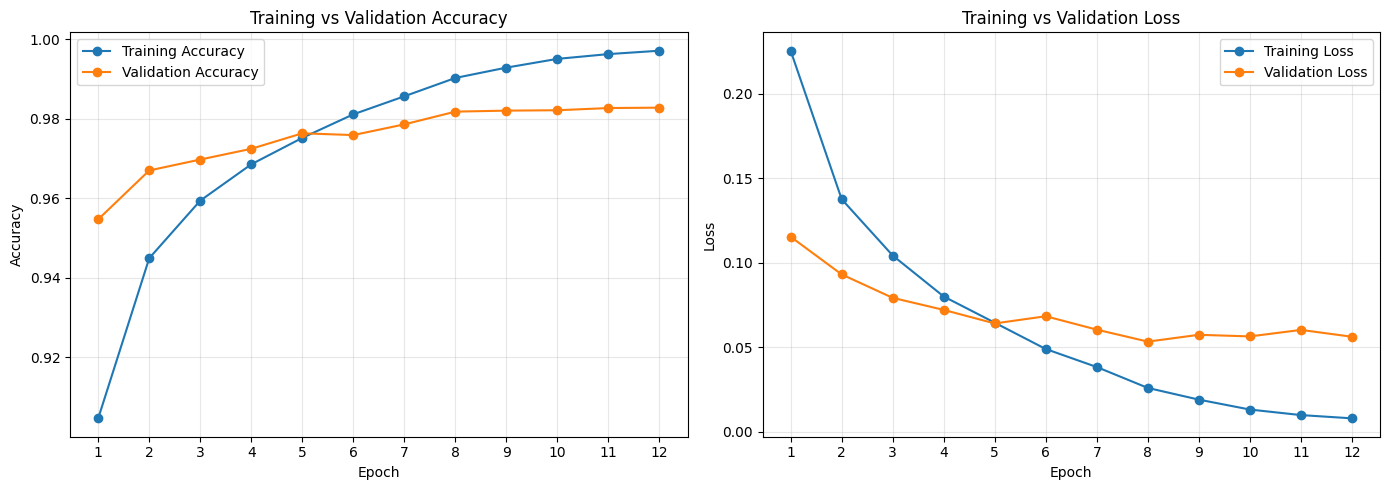

Training graphs generated.


In [19]:
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    epochs_range,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Training graphs generated.")

In [20]:
print("=" * 60)
print("LOADING BEST MODEL")
print("=" * 60)

checkpoint = torch.load(best_model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Best model loaded successfully.")
print("Saved class names:", checkpoint["class_names"])
print("Model ready for final testing.")

LOADING BEST MODEL
Best model loaded successfully.
Saved class names: ['FAKE', 'REAL']
Model ready for final testing.


In [21]:
print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

test_loss, test_accuracy, y_true, y_pred, y_prob = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

FINAL TEST EVALUATION


Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Test Loss:     0.0549
Test Accuracy: 0.9832


In [22]:
precision = precision_score(
    y_true,
    y_pred,
    average="binary",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="binary",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="binary",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_prob[:, 1]
)

accuracy = accuracy_score(y_true, y_pred)

print("=" * 60)
print("FINAL PERFORMANCE METRICS")
print("=" * 60)

print(f"Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1-Score:    {f1:.4f}")
print(f"Macro-F1:    {macro_f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")

FINAL PERFORMANCE METRICS
Accuracy:    0.9832 (98.32%)
Precision:   0.9831
Recall:      0.9834
F1-Score:    0.9833
Macro-F1:    0.9832
ROC-AUC:     0.9987


In [23]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE     0.9834    0.9831    0.9832     10000
        REAL     0.9831    0.9834    0.9833     10000

    accuracy                         0.9832     20000
   macro avg     0.9833    0.9832    0.9832     20000
weighted avg     0.9833    0.9832    0.9832     20000



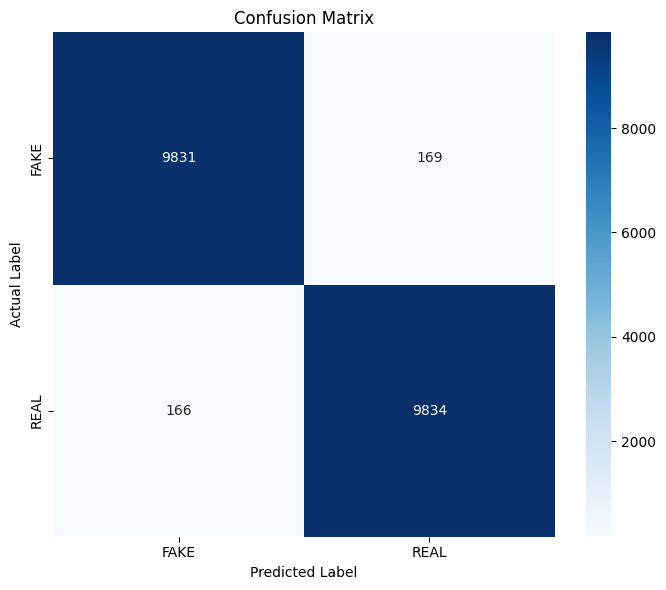

CONFUSION MATRIX VALUES
Rows = Actual classes
Columns = Predicted classes

[[9831  169]
 [ 166 9834]]

Interpretation:
Correct predictions: 19,665
Incorrect predictions: 335


In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

print("=" * 60)
print("CONFUSION MATRIX VALUES")
print("=" * 60)

print("Rows = Actual classes")
print("Columns = Predicted classes")
print()

print(cm)

print("\nInterpretation:")
print(f"Correct predictions: {np.trace(cm):,}")
print(f"Incorrect predictions: {cm.sum() - np.trace(cm):,}")

In [25]:
tn, fp, fn, tp = cm.ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

print(f"\nFalse Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

ERROR ANALYSIS
True Negatives:  9,831
False Positives: 169
False Negatives: 166
True Positives:  9,834

False Positive Rate: 0.0169
False Negative Rate: 0.0166


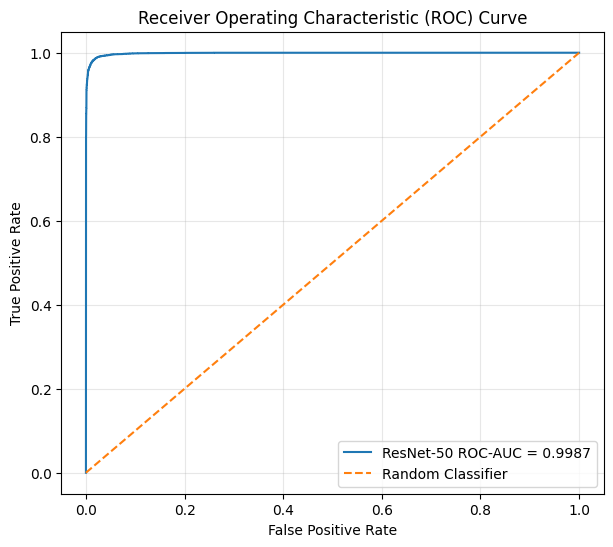

ROC curve generated.
ROC-AUC Score: 0.9987


In [26]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet-50 ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("ROC curve generated.")
print(f"ROC-AUC Score: {roc_auc:.4f}")

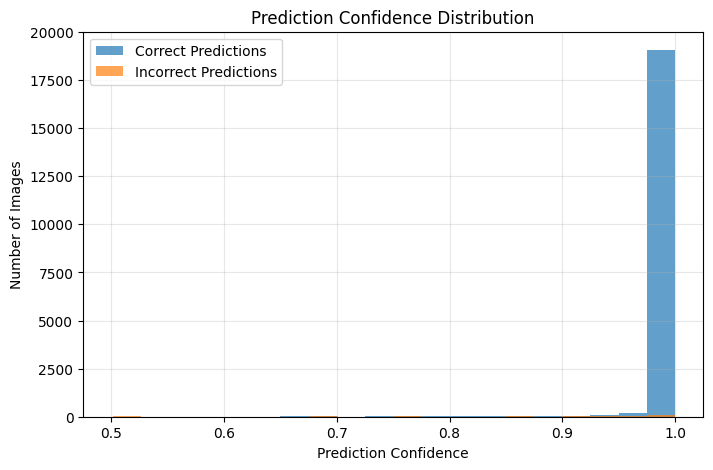

CONFIDENCE ANALYSIS
Average confidence: 0.9928
Average correct prediction confidence: 0.9954
Average incorrect prediction confidence: 0.8410


In [27]:
confidence = np.max(y_prob, axis=1)

correct_mask = y_true == y_pred
incorrect_mask = y_true != y_pred

plt.figure(figsize=(8, 5))

plt.hist(
    confidence[correct_mask],
    bins=20,
    alpha=0.7,
    label="Correct Predictions"
)

plt.hist(
    confidence[incorrect_mask],
    bins=20,
    alpha=0.7,
    label="Incorrect Predictions"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("=" * 60)
print("CONFIDENCE ANALYSIS")
print("=" * 60)

print(f"Average confidence: {confidence.mean():.4f}")
print(f"Average correct prediction confidence: {confidence[correct_mask].mean():.4f}")

if incorrect_mask.sum() > 0:
    print(
        f"Average incorrect prediction confidence: "
        f"{confidence[incorrect_mask].mean():.4f}"
    )
else:
    print("No incorrect predictions found.")

MISCLASSIFICATION ANALYSIS
Total test images: 20000
Misclassified images: 335
Misclassification rate: 1.68%


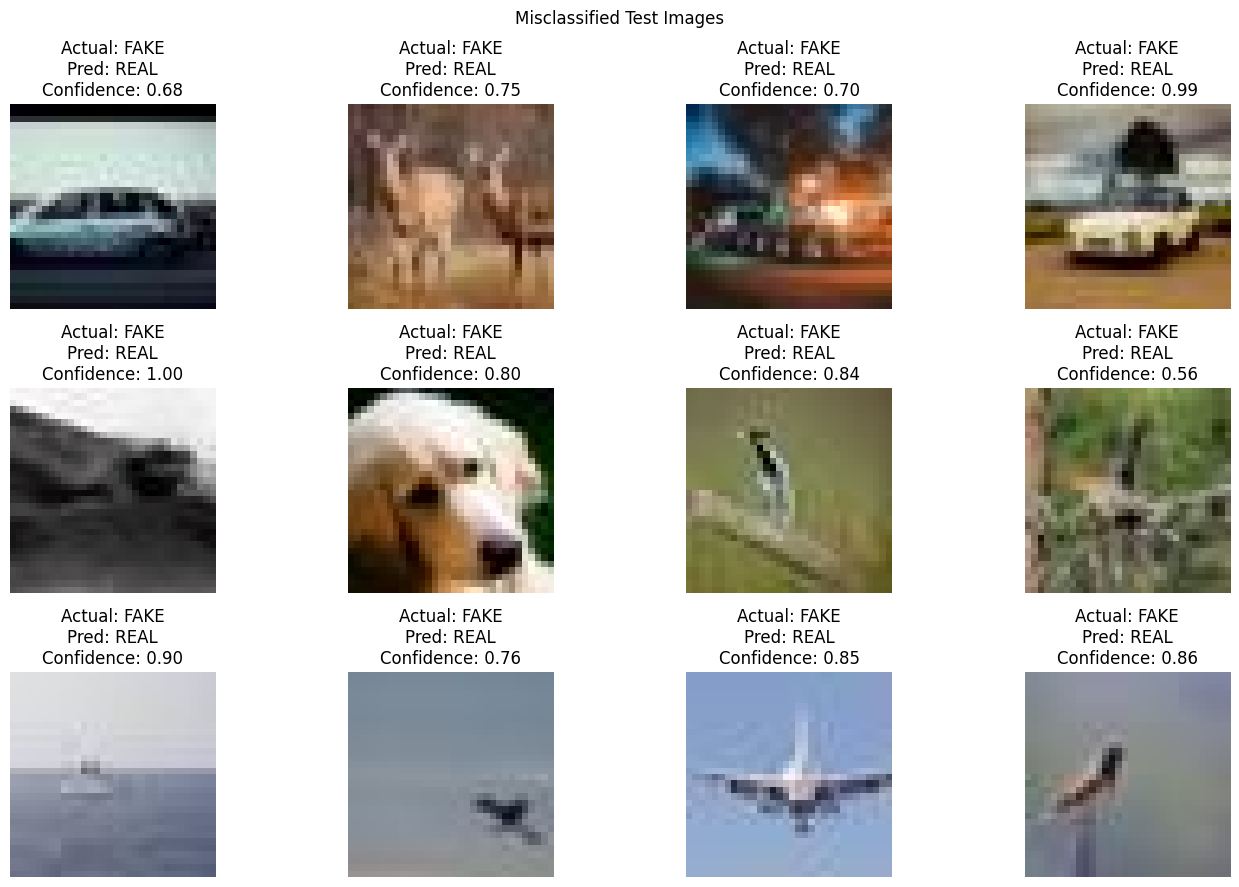

Misclassified images displayed.


In [28]:
# Use the non-augmented evaluation dataset for visualization
all_test_images = test_dataset

misclassified_indices = np.where(y_true != y_pred)[0]

print("=" * 60)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 60)

print("Total test images:", len(y_true))
print("Misclassified images:", len(misclassified_indices))
print(
    "Misclassification rate:",
    f"{len(misclassified_indices)/len(y_true)*100:.2f}%"
)

num_to_display = min(12, len(misclassified_indices))

if num_to_display > 0:
    plt.figure(figsize=(14, 9))

    for i in range(num_to_display):
        idx = misclassified_indices[i]

        image, actual_label = all_test_images[idx]

        image = denormalize(image).permute(1, 2, 0).numpy()

        predicted_label = y_pred[idx]
        confidence_value = confidence[idx]

        plt.subplot(3, 4, i + 1)
        plt.imshow(image)

        plt.title(
            f"Actual: {class_names[actual_label]}\n"
            f"Pred: {class_names[predicted_label]}\n"
            f"Confidence: {confidence_value:.2f}"
        )

        plt.axis("off")

    plt.suptitle("Misclassified Test Images")
    plt.tight_layout()
    plt.show()

    print("Misclassified images displayed.")
else:
    print("No misclassified images found.")

In [29]:
results = {
    "model": "ResNet-50-Native32",
    "dataset": "CIFAKE",
    "image_size": IMG_SIZE,
    "classes": class_names,
    "train_images": len(train_dataset),
    "validation_images": len(val_dataset),
    "test_images": len(test_dataset),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "macro_f1": float(macro_f1),
    "roc_auc": float(roc_auc),
    "false_positive_rate": float(false_positive_rate),
    "false_negative_rate": float(false_negative_rate)
}

results_path = "/content/cifake_resnet50_native32_results.json"

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

final_model_path = "/content/cifake_resnet50_native32_final.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "results": results
}, final_model_path)

print("=" * 60)
print("FILES SAVED")
print("=" * 60)

print("Model:", final_model_path)
print("Results:", results_path)

FILES SAVED
Model: /content/cifake_resnet50_native32_final.pth
Results: /content/cifake_resnet50_native32_results.json


In [30]:
print("\n" + "=" * 70)
print("SIGNALSCOPE — FINAL MODEL EVALUATION SUMMARY")
print("=" * 70)

print(f"Dataset: CIFAKE")
print(f"Model: ResNet-50 (Native 32x32)")
print(f"Classes: {class_names}")
print(f"Training images: {len(train_dataset):,}")
print(f"Validation images: {len(val_dataset):,}")
print(f"Test images: {len(test_dataset):,}")

print("\nPERFORMANCE")
print("-" * 70)
print(f"Accuracy:           {accuracy*100:.2f}%")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1-Score:           {f1:.4f}")
print(f"Macro-F1:           {macro_f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"False Positive Rate:{false_positive_rate:.4f}")
print(f"False Negative Rate:{false_negative_rate:.4f}")

print("\nCONFUSION MATRIX")
print("-" * 70)
print(cm)

print("\nTRAINING")
print("-" * 70)
print(f"Epochs completed: {NUM_EPOCHS}")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

print("\nFiles:")
print(f"Model saved at: {final_model_path}")
print(f"Results saved at: {results_path}")

print("=" * 70)


SIGNALSCOPE — FINAL MODEL EVALUATION SUMMARY
Dataset: CIFAKE
Model: ResNet-50 (Native 32x32)
Classes: ['FAKE', 'REAL']
Training images: 80,000
Validation images: 20,000
Test images: 20,000

PERFORMANCE
----------------------------------------------------------------------
Accuracy:           98.32%
Precision:          0.9831
Recall:             0.9834
F1-Score:           0.9833
Macro-F1:           0.9832
ROC-AUC:            0.9987
False Positive Rate:0.0169
False Negative Rate:0.0166

CONFUSION MATRIX
----------------------------------------------------------------------
[[9831  169]
 [ 166 9834]]

TRAINING
----------------------------------------------------------------------
Epochs completed: 12
Best validation accuracy: 0.0000

Files:
Model saved at: /content/cifake_resnet50_native32_final.pth
Results saved at: /content/cifake_resnet50_native32_results.json


FINAL COMPREHENSIVE MODEL EVALUATION
Best model loaded successfully.
Model path: /content/best_resnet50_cifake_native32.pth
Device: cuda

MODEL INFORMATION
Architecture: ResNet-50 (Native 32x32)
Total Parameters: 23,504,450
Trainable Parameters: 23,504,450
Number of Test Samples: 20,000
Classes: ['FAKE', 'REAL']

TEST INFERENCE COMPLETED
Test Samples: 20,000
Test Loss: 0.0549
Test Accuracy: 0.9832 (98.32%)
Inference Time: 21.83 seconds
Images/Second: 916.38

COMPLETE EVALUATION METRICS


,Metric,Value
0,Test Loss,0.0549
1,Accuracy,0.9832
2,Precision (Macro),0.9833
3,Recall (Macro),0.9832
4,F1 Score (Macro),0.9832
5,Precision (Weighted),0.9833
6,Recall (Weighted),0.9832
7,F1 Score (Weighted),0.9832
8,Macro F1 Score,0.9832
9,Balanced Accuracy,0.9832



CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE     0.9834    0.9831    0.9832     10000
        REAL     0.9831    0.9834    0.9833     10000

    accuracy                         0.9832     20000
   macro avg     0.9833    0.9832    0.9832     20000
weighted avg     0.9833    0.9832    0.9832     20000



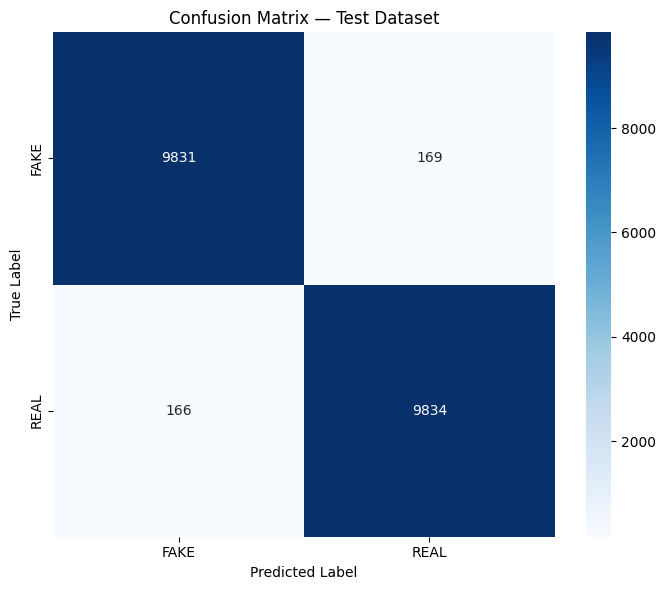


Confusion Matrix Values:
True Negatives (TN):  9,831
False Positives (FP): 169
False Negatives (FN): 166
True Positives (TP):  9,834


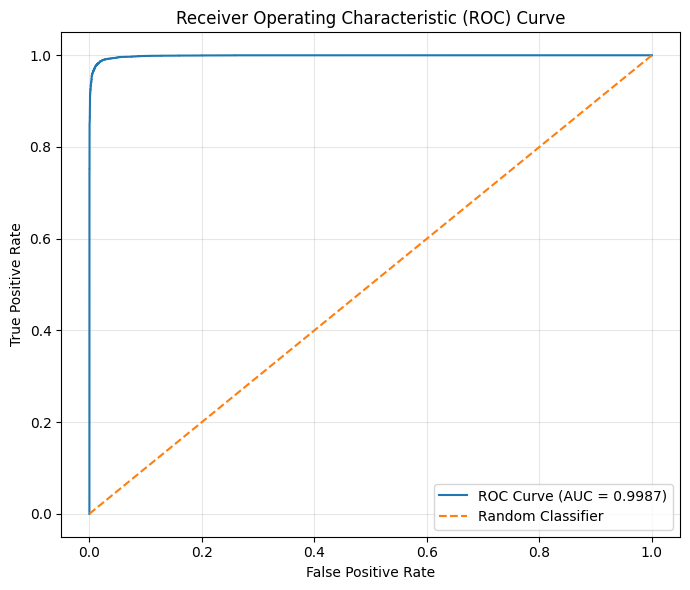

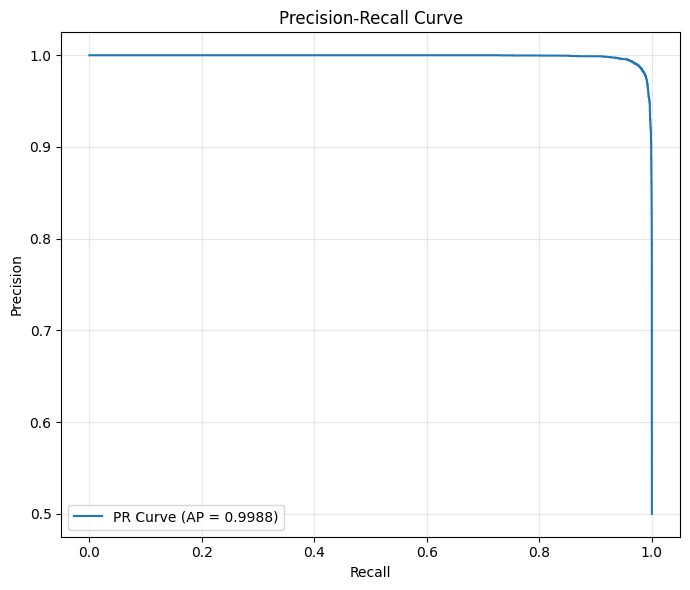

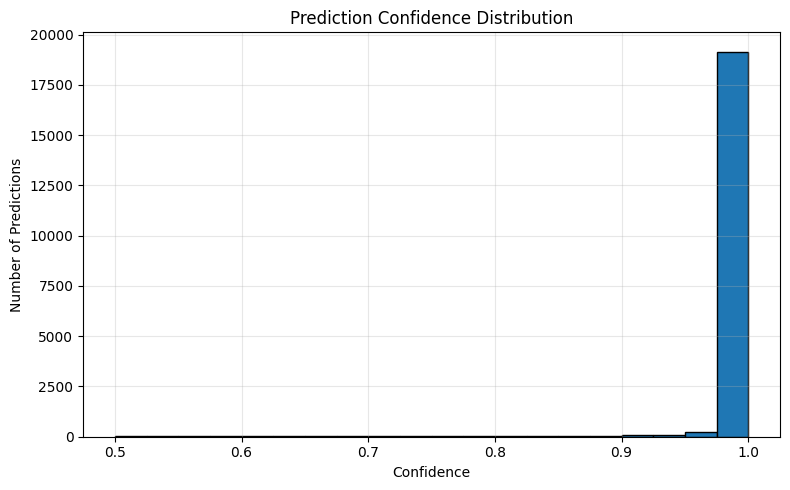

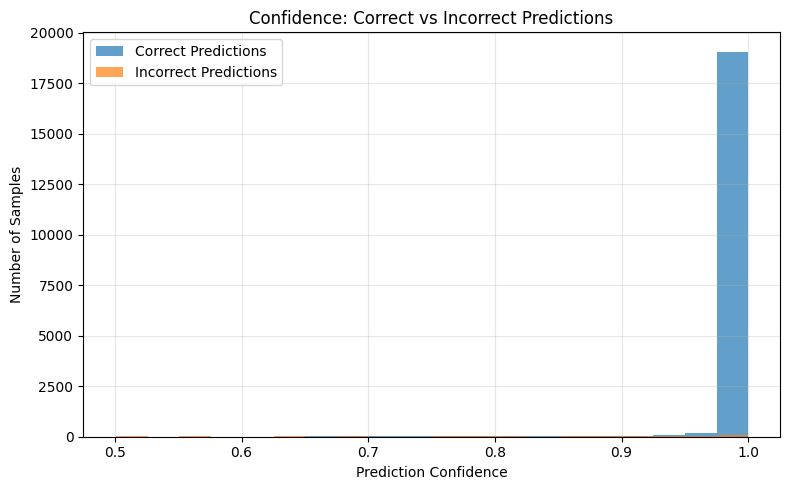


ERROR ANALYSIS
Correct Predictions:   19,665
Incorrect Predictions: 335
Error Count:           335
Error Rate:            1.68%

First 20 Misclassified Samples:


,Index,True Label,Predicted Label,Confidence,Probability Class 0,Probability Class 1
0,11,0,1,0.675610,0.324390,0.675610
1,34,0,1,0.753805,0.246195,0.753805
2,50,0,1,0.696183,0.303817,0.696183
3,51,0,1,0.987782,0.012218,0.987782
4,160,0,1,0.997848,0.002152,0.997848
5,165,0,1,0.803761,0.196239,0.803761
6,172,0,1,0.838066,0.161934,0.838066
7,212,0,1,0.563310,0.436690,0.563310
8,218,0,1,0.903492,0.096508,0.903492
9,352,0,1,0.761963,0.238037,0.761963



MOST UNCERTAIN PREDICTIONS


,Index,True Label,Predicted Label,Confidence,Probability Class 0,Probability Class 1
0,5363,0,0,0.500015,0.500015,0.499985
1,1172,0,1,0.501089,0.498911,0.501089
2,18513,1,0,0.503275,0.503275,0.496725
3,18662,1,0,0.506587,0.506587,0.493413
4,1370,0,1,0.508185,0.491815,0.508185
5,6107,0,0,0.511287,0.511287,0.488713
6,10906,1,0,0.512136,0.512136,0.487864
7,11939,1,0,0.512269,0.512269,0.487731
8,19091,1,0,0.512437,0.512437,0.487563
9,17579,1,1,0.513178,0.486822,0.513178



FINAL PROJECT PERFORMANCE SUMMARY

Model: ResNet-50 (Native 32x32)
Dataset: CIFAKE
Evaluation Set: Original Test Dataset
Training Epochs: 12

Training Accuracy:   99.72%
Validation Accuracy: 98.28%
Test Accuracy:       98.32%

Test Precision (Macro): 0.9833
Test Recall (Macro):    0.9832
Test Macro F1 Score:    0.9832
Test ROC-AUC:           0.9987
Test PR-AUC:            0.9988
Balanced Accuracy:      0.9832
Specificity:            0.9831
Sensitivity:            0.9834

Total Test Images:      20,000
Correct Predictions:   19,665
Incorrect Predictions: 335

FINAL EVALUATION COMPLETED SUCCESSFULLY

Saved Files:
/content/final_evaluation_metrics.csv
/content/test_predictions.csv


In [31]:
# ============================================================
# FINAL COMPREHENSIVE EVALUATION — CIFAKE / ResNet-50
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss
)

from IPython.display import display

print("=" * 70)
print("FINAL COMPREHENSIVE MODEL EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD BEST MODEL
# ------------------------------------------------------------

BEST_MODEL_PATH = "/content/best_resnet50_cifake_native32.pth"

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Best model not found at: {BEST_MODEL_PATH}")

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

# Support different checkpoint formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print(f"Best model loaded successfully.")
print(f"Model path: {BEST_MODEL_PATH}")
print(f"Device: {device}")


# ------------------------------------------------------------
# 2. MODEL INFORMATION
# ------------------------------------------------------------

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "=" * 70)
print("MODEL INFORMATION")
print("=" * 70)
print(f"Architecture: ResNet-50 (Native 32x32)")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Number of Test Samples: {len(test_loader.dataset):,}")


# ------------------------------------------------------------
# 3. CLASS NAMES
# ------------------------------------------------------------

if hasattr(test_loader.dataset, "classes"):
    class_names = test_loader.dataset.classes
else:
    class_names = ["FAKE", "REAL"]

print(f"Classes: {class_names}")


# ------------------------------------------------------------
# 4. TEST-SET INFERENCE
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

all_labels = []
all_predictions = []
all_probabilities = []
all_confidences = []

test_loss = 0.0
correct = 0
total = 0

start_time = time.time()

with torch.inference_mode():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)
        probabilities = torch.softmax(outputs, dim=1)

        confidences, predictions = torch.max(probabilities, dim=1)

        test_loss += loss.item() * labels.size(0)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_confidences.extend(confidences.cpu().numpy())

inference_time = time.time() - start_time

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)
all_confidences = np.array(all_confidences)

avg_test_loss = test_loss / total
test_accuracy = correct / total

print("\n" + "=" * 70)
print("TEST INFERENCE COMPLETED")
print("=" * 70)
print(f"Test Samples: {total:,}")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Inference Time: {inference_time:.2f} seconds")
print(f"Images/Second: {total / inference_time:.2f}")


# ------------------------------------------------------------
# 5. CLASSIFICATION METRICS
# ------------------------------------------------------------

precision_macro = precision_score(
    all_labels, all_predictions, average="macro", zero_division=0
)

recall_macro = recall_score(
    all_labels, all_predictions, average="macro", zero_division=0
)

f1_macro = f1_score(
    all_labels, all_predictions, average="macro", zero_division=0
)

precision_weighted = precision_score(
    all_labels, all_predictions, average="weighted", zero_division=0
)

recall_weighted = recall_score(
    all_labels, all_predictions, average="weighted", zero_division=0
)

f1_weighted = f1_score(
    all_labels, all_predictions, average="weighted", zero_division=0
)

balanced_acc = balanced_accuracy_score(
    all_labels, all_predictions
)

mcc = matthews_corrcoef(
    all_labels, all_predictions
)

kappa = cohen_kappa_score(
    all_labels, all_predictions
)

# AUC metrics
try:
    roc_auc = roc_auc_score(
        all_labels,
        all_probabilities[:, 1]
    )
except ValueError:
    roc_auc = float("nan")

try:
    pr_auc = average_precision_score(
        all_labels,
        all_probabilities[:, 1]
    )
except ValueError:
    pr_auc = float("nan")


# ------------------------------------------------------------
# 6. CONFUSION MATRIX VALUES
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0


# ------------------------------------------------------------
# 7. COMPLETE METRICS TABLE
# ------------------------------------------------------------

metrics_table = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 Score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1 Score (Weighted)",
        "Macro F1 Score",
        "Balanced Accuracy",
        "ROC-AUC",
        "PR-AUC",
        "Sensitivity / Recall",
        "Specificity",
        "Matthews Correlation Coefficient",
        "Cohen's Kappa",
        "Average Confidence",
        "Inference Time (seconds)",
        "Inference Speed (images/sec)"
    ],
    "Value": [
        avg_test_loss,
        test_accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        f1_macro,
        balanced_acc,
        roc_auc,
        pr_auc,
        sensitivity,
        specificity,
        mcc,
        kappa,
        np.mean(all_confidences),
        inference_time,
        total / inference_time
    ]
})

print("\n" + "=" * 70)
print("COMPLETE EVALUATION METRICS")
print("=" * 70)

display(
    metrics_table.style.format({
        "Value": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 8. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)


# ------------------------------------------------------------
# 9. CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix — Test Dataset")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Values:")
print(f"True Negatives (TN):  {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives (TP):  {tp:,}")


# ------------------------------------------------------------
# 10. ROC CURVE
# ------------------------------------------------------------

if not np.isnan(roc_auc):

    fpr, tpr, roc_thresholds = roc_curve(
        all_labels,
        all_probabilities[:, 1]
    )

    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        label=f"ROC Curve (AUC = {roc_auc:.4f})"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 11. PRECISION-RECALL CURVE
# ------------------------------------------------------------

if not np.isnan(pr_auc):

    precision_values, recall_values, pr_thresholds = precision_recall_curve(
        all_labels,
        all_probabilities[:, 1]
    )

    plt.figure(figsize=(7, 6))

    plt.plot(
        recall_values,
        precision_values,
        label=f"PR Curve (AP = {pr_auc:.4f})"
    )

    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 12. CONFIDENCE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    all_confidences,
    bins=20,
    edgecolor="black"
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Predictions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. CORRECT VS INCORRECT PREDICTIONS
# ------------------------------------------------------------

correct_mask = all_labels == all_predictions
incorrect_mask = ~correct_mask

correct_confidences = all_confidences[correct_mask]
incorrect_confidences = all_confidences[incorrect_mask]

plt.figure(figsize=(8, 5))

plt.hist(
    correct_confidences,
    bins=20,
    alpha=0.7,
    label="Correct Predictions"
)

plt.hist(
    incorrect_confidences,
    bins=20,
    alpha=0.7,
    label="Incorrect Predictions"
)

plt.title("Confidence: Correct vs Incorrect Predictions")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. ERROR ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print(f"Correct Predictions:   {correct_mask.sum():,}")
print(f"Incorrect Predictions: {incorrect_mask.sum():,}")
print(f"Error Count:           {incorrect_mask.sum():,}")
print(f"Error Rate:            {(1 - test_accuracy) * 100:.2f}%")

if incorrect_mask.sum() > 0:

    incorrect_indices = np.where(incorrect_mask)[0]

    error_data = pd.DataFrame({
        "Index": incorrect_indices,
        "True Label": all_labels[incorrect_indices],
        "Predicted Label": all_predictions[incorrect_indices],
        "Confidence": all_confidences[incorrect_indices],
        "Probability Class 0": all_probabilities[incorrect_indices, 0],
        "Probability Class 1": all_probabilities[incorrect_indices, 1]
    })

    print("\nFirst 20 Misclassified Samples:")
    display(error_data.head(20))


# ------------------------------------------------------------
# 15. MOST UNCERTAIN PREDICTIONS
# ------------------------------------------------------------

uncertainty = 1 - all_confidences
uncertain_indices = np.argsort(uncertainty)[::-1][:20]

uncertain_data = pd.DataFrame({
    "Index": uncertain_indices,
    "True Label": all_labels[uncertain_indices],
    "Predicted Label": all_predictions[uncertain_indices],
    "Confidence": all_confidences[uncertain_indices],
    "Probability Class 0": all_probabilities[uncertain_indices, 0],
    "Probability Class 1": all_probabilities[uncertain_indices, 1]
})

print("\n" + "=" * 70)
print("MOST UNCERTAIN PREDICTIONS")
print("=" * 70)

display(uncertain_data)


# ------------------------------------------------------------
# 16. FINAL PROJECT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PROJECT PERFORMANCE SUMMARY")
print("=" * 70)

print(f"""
Model: ResNet-50 (Native 32x32)
Dataset: CIFAKE
Evaluation Set: Original Test Dataset
Training Epochs: {NUM_EPOCHS}

Training Accuracy:   {history["train_accuracy"][-1] * 100:.2f}%
Validation Accuracy: {history["val_accuracy"][-1] * 100:.2f}%
Test Accuracy:       {test_accuracy * 100:.2f}%

Test Precision (Macro): {precision_macro:.4f}
Test Recall (Macro):    {recall_macro:.4f}
Test Macro F1 Score:    {f1_macro:.4f}
Test ROC-AUC:           {roc_auc:.4f}
Test PR-AUC:            {pr_auc:.4f}
Balanced Accuracy:      {balanced_acc:.4f}
Specificity:            {specificity:.4f}
Sensitivity:            {sensitivity:.4f}

Total Test Images:      {total:,}
Correct Predictions:   {correct_mask.sum():,}
Incorrect Predictions: {incorrect_mask.sum():,}
""")

print("=" * 70)
print("FINAL EVALUATION COMPLETED SUCCESSFULLY")
print("=" * 70)


# ------------------------------------------------------------
# 17. SAVE METRICS AND PREDICTIONS
# ------------------------------------------------------------

metrics_table.to_csv(
    "/content/final_evaluation_metrics.csv",
    index=False
)

predictions_df = pd.DataFrame({
    "True Label": all_labels,
    "Predicted Label": all_predictions,
    "Confidence": all_confidences,
    "Probability Class 0": all_probabilities[:, 0],
    "Probability Class 1": all_probabilities[:, 1]
})

predictions_df.to_csv(
    "/content/test_predictions.csv",
    index=False
)

print("\nSaved Files:")
print("/content/final_evaluation_metrics.csv")
print("/content/test_predictions.csv")

In [32]:
from google.colab import files

files.download("/content/best_resnet50_cifake_native32.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files

files.download("/content/final_evaluation_metrics.csv")
files.download("/content/test_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

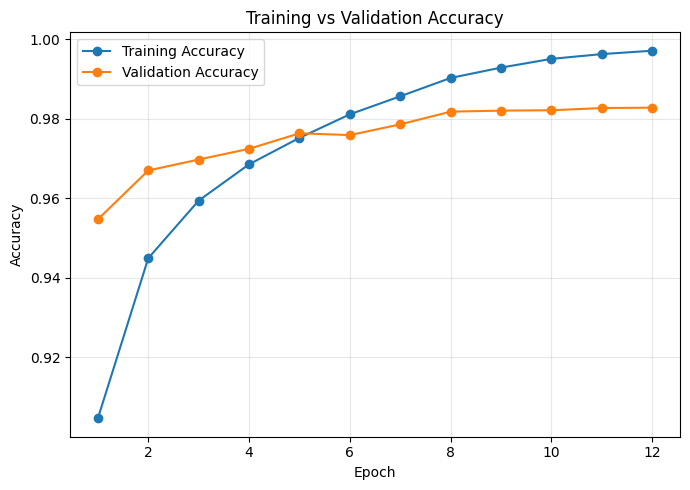

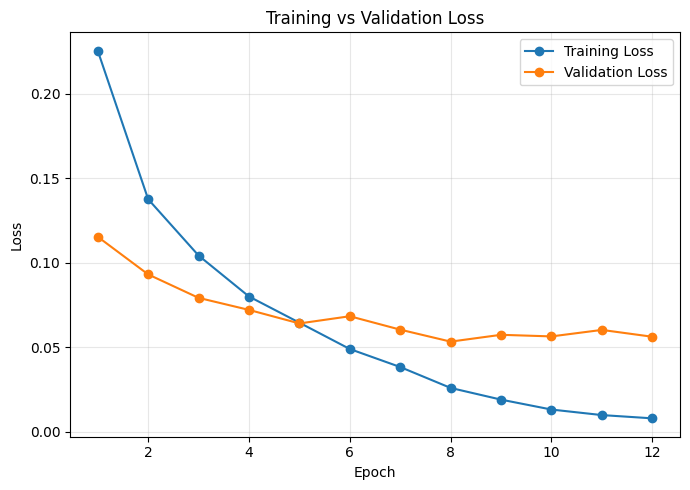

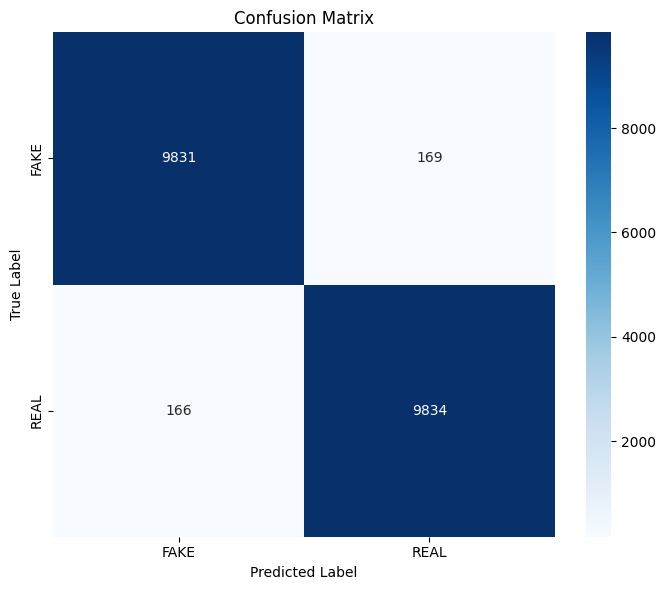

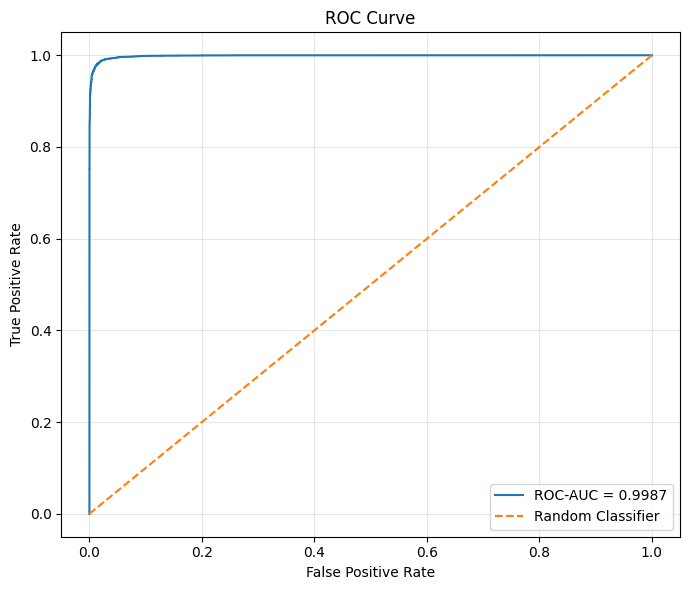

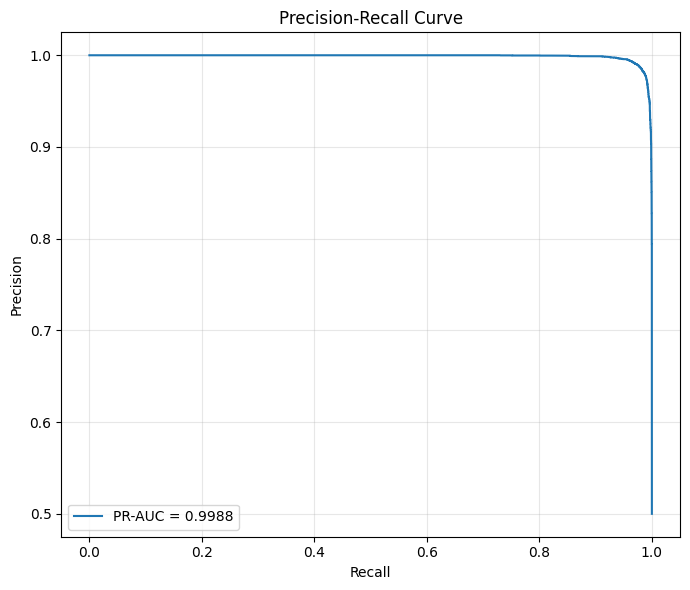

All graphs saved in /content/project_outputs/


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("/content/project_outputs", exist_ok=True)

# Accuracy graph
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/project_outputs/training_validation_accuracy.png", dpi=300)
plt.show()


# Loss graph
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/project_outputs/training_validation_loss.png", dpi=300)
plt.show()


# Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("/content/project_outputs/confusion_matrix.png", dpi=300)
plt.show()


# ROC Curve
if not np.isnan(roc_auc):
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/project_outputs/roc_curve.png", dpi=300)
    plt.show()


# Precision-Recall Curve
if not np.isnan(pr_auc):
    plt.figure(figsize=(7, 6))
    plt.plot(
        recall_values,
        precision_values,
        label=f"PR-AUC = {pr_auc:.4f}"
    )
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/content/project_outputs/precision_recall_curve.png", dpi=300)
    plt.show()

print("All graphs saved in /content/project_outputs/")

In [35]:
import shutil
from google.colab import files

shutil.make_archive(
    "/content/project_outputs",
    "zip",
    "/content/project_outputs"
)

files.download("/content/project_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>